In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
dataset_train = pd.read_csv('Salestrain.csv')
dataset_train.shape

(96, 1)

In [3]:
dataset_test = pd.read_csv('Salestest.csv')
dataset_test.shape

(48, 1)

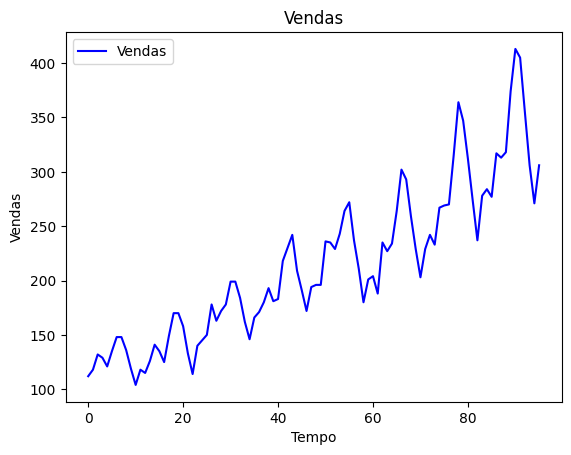

In [4]:
plt.plot(dataset_train, color='blue', label='Vendas')
plt.title('Vendas')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [5]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(dataset_train)

In [6]:
X_train = []
y_train = []
for i in range(90, len(training_set_scaled)):
  data = training_set_scaled[i-90:i, 0]
  X_train.append(data)
  y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train).reshape(-1, 90, 1)
y_train = np.array(y_train)

In [7]:
model = Sequential()
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=100))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=300, batch_size=1)

Epoch 1/300


/Users/caio.motta/.pyenv/versions/3.11.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.4955
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0373
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.1064
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0518
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.1141
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0435
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0664
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0385
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0340
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0546
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0353
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0273
Epoch 13/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0561
Epoch 14/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0331
Epoch 15/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0434
Epoch 16/300
6/6 ━━━━━━━━━━━━━━

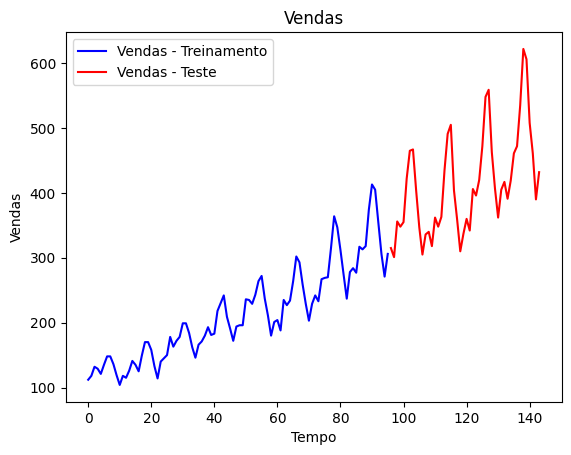

In [9]:
train_values = dataset_train['data'].values
test_values = dataset_test['data'].values
total_values = np.concatenate((train_values, test_values), axis=0)
time_index = range(len(total_values))
plt.plot(time_index[:len(train_values)], train_values, color='blue', label='Vendas - Treinamento')
plt.plot(time_index[len(train_values):], test_values, color='red', label='Vendas - Teste')
plt.title('Vendas')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [11]:
dataset_test_anomalies = dataset_test.copy()
dataset_test_anomalies.loc[:9, 'data'] = 90
dataset_test_anomalies.loc[10:34, 'data'] = np.random.uniform(100, 200, size=(25,))
dataset_test_anomalies.loc[35:, 'data'] = 90

/var/folders/mk/8ytm3sv94s7d059pz1q71blc0000gn/T/ipykernel_93654/3170998761.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[101.23127427 136.55094074 147.06500311 156.90791734 188.09592612
 138.39899174 178.57672077 154.91802859 126.21121268 156.05321333
 103.05783806 172.79318688 151.95132858 126.53081753 155.77524597
 102.72520914 165.76843334 114.0950471  129.12805886 156.85285778
 196.94578071 118.01817132 110.00152052 129.93288256 117.16206317]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset_test_anomalies.loc[10:34, 'data'] = np.random.uniform(100, 200, size=(25,))


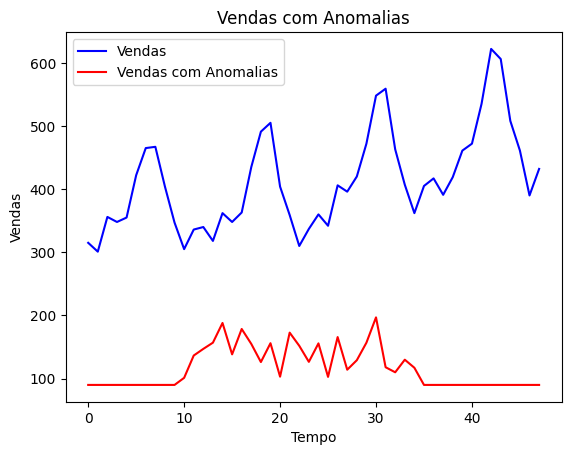

In [12]:
plt.plot(dataset_test, color='blue', label='Vendas')
plt.plot(dataset_test_anomalies, color='red', label='Vendas com Anomalias')
plt.title('Vendas com Anomalias')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [15]:
dataset_total = pd.concat((dataset_train['data'], dataset_test['data']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 90:].values
inputs = pd.DataFrame(inputs, columns=['data'])
inputs = sc.transform(inputs)

In [22]:
dataset_total_anomalies = pd.concat((dataset_train['data'], dataset_test_anomalies['data']), axis=0)
inputs_anomalies = dataset_total_anomalies[len(dataset_total_anomalies) - len(dataset_test_anomalies) - 90:].values
inputs_anomalies = pd.DataFrame(inputs_anomalies, columns=['data'])
inputs_anomalies = sc.transform(inputs_anomalies)

In [23]:
X_test = []
X_test_anomalies = []
for i in range(90, len(inputs)):
  X_test.append(inputs[i-90:i, 0])
  X_test_anomalies.append(inputs_anomalies[i-90:i, 0])
X_test, X_test_anomalies = np.array(X_test), np.array(X_test_anomalies)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_test_anomalies = np.reshape(X_test_anomalies, (X_test_anomalies.shape[0], X_test_anomalies.shape[1], 1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


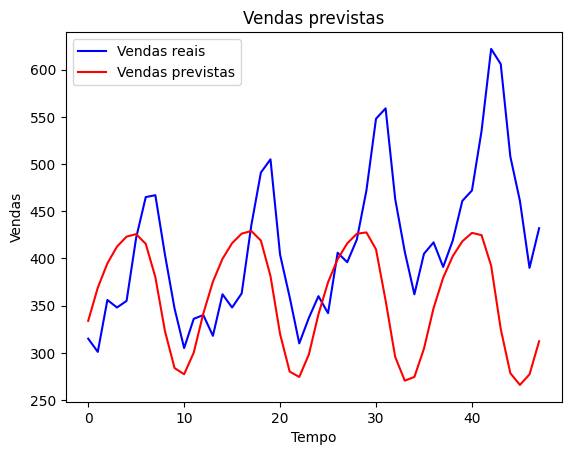

In [24]:
predicted_sales = model.predict(X_test)
predicted_sales = sc.inverse_transform(predicted_sales)
predicted_sales_anomalies = model.predict(X_test_anomalies)
predicted_sales_anomalies = sc.inverse_transform(predicted_sales_anomalies)
real_sales = dataset_test.values
real_sales_anomalies = dataset_test_anomalies.values
plt.plot(real_sales, color='blue', label='Vendas reais')
plt.plot(predicted_sales, color='red', label='Vendas previstas')
plt.title('Vendas previstas')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [25]:
mes_test = mean_squared_error(test_values, predicted_sales)
mes_test_anomalies = mean_squared_error(test_values, predicted_sales_anomalies)

print(f'MSE Teste: {mes_test}')
print(f'MSE Teste com Anomalias: {mes_test_anomalies}')

MSE Teste: 10153.8369140625
MSE Teste com Anomalias: 16781.109375
